In [178]:
import pandas as pd
from pymc_toolkit.pymc_model import PymcModel

data = pd.read_csv('data/Poseidon.csv')

target_name = 'total_revenue'

First, we are going to find the most correlated variables versus target variable ´total_revenue´. We left the last time point to drop and incomplete week

In [179]:
pd.set_option('display.max_rows', None)

pd.DataFrame(data.iloc[:-1,1:].corr()[target_name]).sort_values(target_name)

,total_revenue
google_ads_shopping_clicks,-0.163843
google_ads_shopping_costs,-0.148000
google_ads_shopping_impressions,-0.139068
google_ads_display_clicks,0.074576
google_ads_display_impressions,0.083908
google_ads_display_costs,0.108013
google_ads_video_impressions,0.113068
google_ads_discovery_costs,0.178211
google_ads_discovery_clicks,0.191100
google_ads_video_costs,0.209197


As we can see, we have the total_revenue, also shopify and amazon revenue, so we will thest if the total is the some of both variables.

<Axes: >

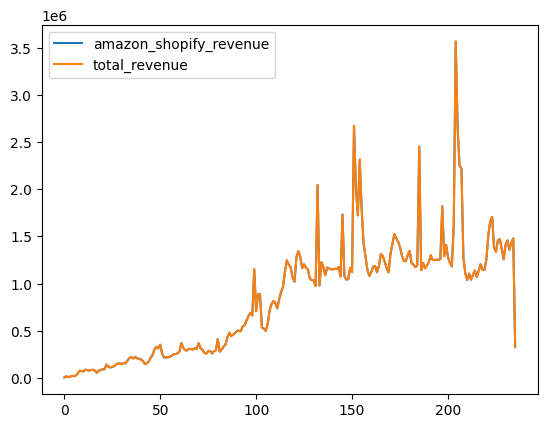

In [182]:
data['amazon_shopify_revenue'] = data['amazon_revenue'] + data['shopify_revenue']
data[['amazon_shopify_revenue', target_name]].plot()

Indeed, so we will repeat the test of correlation with both variables and we will considerate the most correlated variables.

In [183]:
pd.DataFrame(data.iloc[:-1,1:].corr()['amazon_revenue']).sort_values('amazon_revenue')

,amazon_revenue
google_ads_shopping_clicks,-0.133439
google_ads_shopping_costs,-0.122540
google_ads_shopping_impressions,-0.106595
google_ads_display_clicks,0.059849
google_ads_display_impressions,0.066814
google_ads_display_costs,0.088287
google_ads_video_impressions,0.095217
google_ads_discovery_costs,0.153690
google_ads_discovery_clicks,0.175268
google_ads_video_costs,0.183560


We just are going to considerate the most correlated of "costs" type variable.

In [185]:
channel_amazon = ['amazon_ads_spend','google_ads_search_brand_costs', 'google_ads_others_costs']

Repeat con shopify.

In [186]:
pd.DataFrame(data.iloc[:-1,1:].corr()['shopify_revenue']).sort_values('shopify_revenue')

,shopify_revenue
google_ads_shopping_clicks,-0.194413
google_ads_shopping_impressions,-0.175395
google_ads_shopping_costs,-0.172494
google_ads_display_clicks,0.089873
google_ads_display_impressions,0.101935
google_ads_display_costs,0.127672
google_ads_video_impressions,0.129291
google_ads_discovery_clicks,0.196190
google_ads_discovery_costs,0.198150
dsp_spend_others_amazondspspend,0.217393


The shopify variables.

In [187]:
channel_shopify = ['fb_bof_spend', 'google_ads_search_brand_costs', 'fb_toqf_spend', 'google_ads_others_costs']

Now we have the channels variables, and we will considerate the same control variables for benchmark model.

In [188]:
control_names = ['discounts', 'emails_us_total_emails_sent', 'influencers_us_total_reach']
channel_names = list(set(channel_amazon + channel_shopify))
data = data[['total_revenue', 'date_week'] + control_names + channel_names].copy()

model = PymcModel(client_data=data,
             target_name=target_name,
             date_column='date_week',
             channel_names=channel_names,
             control_names=control_names,
             lag_max=1,
             scale_data=True,
             saturation='michaelis_menten',
             time_varying_media=True)

INFO:pymc_toolkit.pymc_model:Creating the client's data configuration.
INFO:pymc_toolkit.client_config:Validate Client's data
INFO:pymc_toolkit.client_config:Validate Media channels
INFO:pymc_toolkit.client_config:available channels:['amazon_ads_spend', 'fb_bof_spend', 'fb_tof_spend', 'google_ads_others_costs', 'google_ads_search_brand_costs']
INFO:pymc_toolkit.client_config:Validate control channels
INFO:pymc_toolkit.client_config:available controls:['discounts', 'emails_us_total_emails_sent', 'influencers_us_total_reach']
INFO:pymc_toolkit.client_config:Identify unused columns from client's data
INFO:pymc_toolkit.client_config:Target variable scaled using MaxAbsScaler.
INFO:pymc_toolkit.client_config:Channel variables scaled using MaxAbsScaler.
INFO:pymc_toolkit.client_config:Control variables scaled using MaxAbsScaler.
INFO:pymc_toolkit.client_config:Client data loaded for 'client0'.
INFO:pymc_toolkit.pymc_model:Set up PyMCModel's basic configuration.
INFO:pymc_toolkit.pymc_model:De

In [190]:
pfleet = model.production_fleet(n_test=12, chains=4, draws=1000,tune=500,cores=4)
pfleet.summary()

INFO:pymc_toolkit.pymc_model:12 steps out of sample production fleet.
INFO:pymc_toolkit.client_config:Returning channels in scaled form.
INFO:pymc_toolkit.client_config:Returning controls in scaled form.
INFO:pymc_toolkit.client_config:Covariates DataFrame constructed with shape (236, 9).
INFO:pymc_toolkit.client_config:Returning target in original scale.
INFO:pymc_toolkit.utils:Total samples: 236
INFO:pymc_toolkit.utils:Single split: train size = 224, test size = 12
INFO:pymc_toolkit.pymc_model:Sampling MMM using 4 chains, 1000 draws, and 500 tuning steps.
Initializing NUTS using adapt_diag...
INFO:pymc.sampling.mcmc:Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, adstock_alpha, saturation_alpha, saturation_lam, media_temporal_latent_multiplier_raw_eta, media_temporal_latent_multiplier_raw_ls, media_temporal_latent_multiplier_raw_hsgp_coefs_offset, gamma_control, y_sig

Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 26 seconds.
INFO:pymc.sampling.mcmc:Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 26 seconds.


Output()

INFO:pymc_toolkit.pymc_model:Sampling completed.
INFO:pymc_toolkit.pymc_model:Predict 12-steps out of sample.
Sampling: [y]
INFO:pymc.sampling.forward:Sampling: [y]


Output()

INFO:pymc_toolkit.fleet_result:Initializing FleetResult...
INFO:pymc_toolkit.fleet_result:Computing in-sample predictions (y_fit)...
Sampling: [y]
INFO:pymc.sampling.forward:Sampling: [y]
INFO:pymc_toolkit.fleet_result:In-sample predictions computed.
INFO:pymc_toolkit.fleet_result:Test set detected — in-sample fit computed.
INFO:pymc_toolkit.fleet_result:Generating diagnostics summary...
INFO:pymc_toolkit.fleet_result:Retrieving MCMC diagnostics...
INFO:pymc_toolkit.fleet_result:MCMC diagnostics retrieved.
INFO:pymc_toolkit.fleet_result:Calculating train metrics...
INFO:pymc_toolkit.fleet_result:Train metrics calculated.
INFO:pymc_toolkit.fleet_result:Calculating test metrics...
INFO:pymc_toolkit.fleet_result:Test metrics calculated.
INFO:pymc_toolkit.fleet_result:Diagnostics summary generated.


{'divergences': 0,
 'max_tree_depth': 7,
 'train': {'mape': 0.4978034058289101,
  'nrmse': 0.03757440676234797,
  'r_squared': 0.9533945806295772,
  'crps_error': 0.058002170769404664},
 'test': {'mape': 0.12033612922400466,
  'nrmse': 0.1486931591305023,
  'r_squared': 0.8184116603503477,
  'crps_error': 0.051176975446242494}}

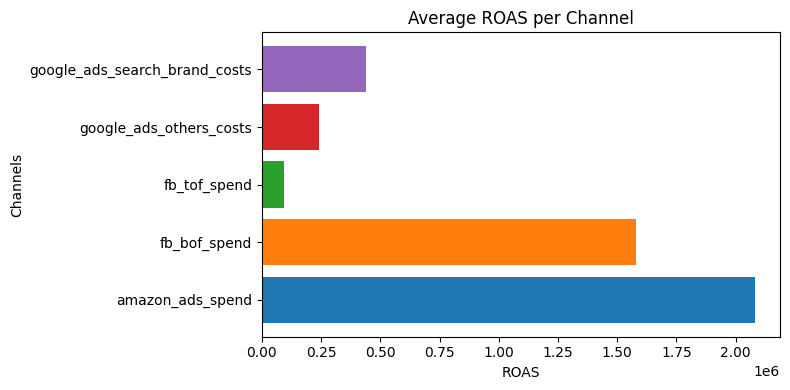

Sampling: [y]
INFO:pymc.sampling.forward:Sampling: [y]
INFO:pymc_toolkit.fleet_result:Calculating train metrics...
INFO:pymc_toolkit.fleet_result:Train metrics calculated.
INFO:pymc_toolkit.fleet_result:Retrieving MCMC diagnostics...
INFO:pymc_toolkit.fleet_result:MCMC diagnostics retrieved.
INFO:pymc_toolkit.fleet_result:Calculating test metrics...
INFO:pymc_toolkit.fleet_result:Test metrics calculated.


'/Users/grios/cassandra/pymc_proyect/toy_prod_fleet_new.html'

In [191]:
pfleet.generate_report(output_html="toy_prod_fleet_new.html")

Default Model – Baseline / More Complex Specification

The default model shows moderate explanatory power with an out-of-sample around 0.50 and relatively high MAPE (≈32%) on test data. While in-sample fit is strong, the gap between training and test performance suggests overfitting or excessive model complexity.

From a Bayesian diagnostics perspective, the model is technically sound: no divergences and good effective sample sizes. However, the large number of channels and parameters increases uncertainty in attribution and makes the model less robust for forecasting and budget optimization.

Summary:
Good internal fit
Weaker generalization
Higher complexity and attribution uncertainty

New Model – Simplified / Optimized Specification

The second model demonstrates substantially better generalization, with much lower MAPE (≈12%). Both training and test errors are aligned, indicating a better bias–variance trade-off.

MCMC diagnostics are excellent: no divergences, lower tree depth, strong effective sample sizes, and stable posterior estimates. The reduced parameter space leads to clearer channel effects, more reliable saturation and adstock estimates, and improved interpretability for decision-making.

Summary:

Strong predictive accuracy
Robust out-of-sample performance
Clearer, more actionable media insights

Overall Conclusion

Default Model is useful for exploratory analysis, New Model is clearly superior for production use, budget allocation, and strategic decision-making. It delivers higher predictive accuracy, stronger stability, and better interpretability, making it the preferred MMM for optimization and scenario planning.